In [2]:
# 필요한 라이브러리를 임포트합니다.
# Torch는 모델/학습, PIL/Matplotlib은 이미지 처리와 시각화를 담당합니다.

import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


In [3]:
# JSRT 데이터 경로를 지정하고, 이미지/마스크 개수를 확인합니다.
# 데이터 개수 불일치 여부를 빠르게 확인하는 체크 단계입니다.

import os

IMAGE_DIR = "../datasets/jsrt/content/jsrt/cxr"
MASK_DIR  = "../datasets/jsrt/content/jsrt/masks"

print("Number of images:", len(os.listdir(IMAGE_DIR)))
print("Number of masks :", len(os.listdir(MASK_DIR)))

Number of images: 247
Number of masks : 247


['JPCLN001.png', 'JPCLN002.png', 'JPCLN003.png', 'JPCLN004.png', 'JPCLN005.png']
['JPCLN001.png', 'JPCLN002.png', 'JPCLN003.png', 'JPCLN004.png', 'JPCLN005.png']
Image size: (224, 224) Mask size: (224, 224)


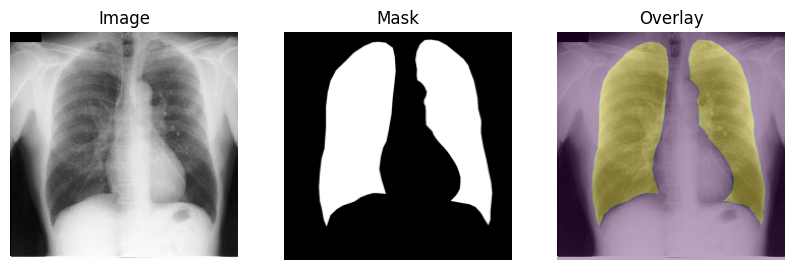

In [4]:
# 파일명을 정렬하여 이미지-마스크 매칭 순서를 맞춥니다.
# 샘플 1장을 시각화해 입력/마스크/오버레이가 정상인지 확인합니다.

import os
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = "../datasets/jsrt/content/jsrt/cxr"
MASK_DIR  = "../datasets/jsrt/content/jsrt/masks"

# 파일 목록 정렬(이미지/마스크 이름을 맞추기 위해 중요)
img_files  = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(".png")])
mask_files = sorted([f for f in os.listdir(MASK_DIR)  if f.lower().endswith(".png")])

print(img_files[:5])
print(mask_files[:5])

# 하나 샘플 확인
idx = 0
img_path  = os.path.join(IMAGE_DIR, img_files[idx])
mask_path = os.path.join(MASK_DIR,  mask_files[idx])

img  = Image.open(img_path).convert("L")
mask = Image.open(mask_path).convert("L")

print("Image size:", img.size, "Mask size:", mask.size)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img, cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("Mask"); plt.imshow(mask, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Overlay")
plt.imshow(img, cmap="gray")
plt.imshow(mask, alpha=0.35)  # 겹쳐보기
plt.axis("off")
plt.show()


In [5]:
# 마스크의 픽셀 값 분포를 확인합니다.
# 이진화 필요 여부(0/255 등)를 판단하기 위한 점검입니다.

import numpy as np

mask_np = np.array(mask)
print("mask unique values (top):", np.unique(mask_np)[:20])
print("mask min/max:", mask_np.min(), mask_np.max())


mask unique values (top): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
mask min/max: 0 255


In [6]:
# JSRT 데이터셋 클래스를 정의합니다.
# 리사이즈 및 텐서 변환을 수행하며, 마스크는 0/1로 이진화합니다.
# train/val 분할과 DataLoader 구성을 포함합니다.

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

class JSRTSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=256):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.size = size

        self.img_files  = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(".png")])
        self.mask_files = sorted([f for f in os.listdir(mask_dir)  if f.lower().endswith(".png")])

        assert len(self.img_files) == len(self.mask_files), "Image/Mask count mismatch"

        # 기본 변환: 리사이즈 + 텐서화
        self.img_tf  = T.Compose([T.Resize((size, size)), T.ToTensor()])  # [0,1]
        self.mask_tf = T.Compose([T.Resize((size, size)), T.ToTensor()])  # [0,1] 근데 0/1로 정리 필요

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path  = os.path.join(self.image_dir, self.img_files[idx])
        mask_path = os.path.join(self.mask_dir,  self.mask_files[idx])

        img  = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img_t  = self.img_tf(img)            # (1,H,W)
        mask_t = self.mask_tf(mask)          # (1,H,W)

        # 마스크를 이진화(0/255 같은 값이면 ToTensor 후 0/1 근처 값이 됩니다)
        mask_t = (mask_t > 0.5).float()

        return img_t, mask_t

dataset = JSRTSegDataset(IMAGE_DIR, MASK_DIR, size=256)
print("Dataset size:", len(dataset))

# train/val split (예: 8:2)
train_size = int(len(dataset) * 0.8)
val_size   = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

x, y = next(iter(train_loader))
print("batch x:", x.shape, x.dtype, "range:", (x.min().item(), x.max().item()))
print("batch y:", y.shape, y.dtype, "unique:", torch.unique(y))

Dataset size: 247
batch x: torch.Size([8, 1, 256, 256]) torch.float32 range: (0.0, 1.0)
batch y: torch.Size([8, 1, 256, 256]) torch.float32 unique: tensor([0., 1.])


In [7]:
# 학습에 사용할 디바이스를 설정합니다.
# macOS에서는 MPS 사용 여부를 확인합니다.

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: mps


In [12]:
# 재현성을 위해 난수 시드를 고정합니다.
# 하이퍼파라미터(배치/에폭/학습률)를 설정합니다.

import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-3


device: mps


In [13]:
# U-Net 모델을 정의합니다.
# Encoder-Decoder 구조와 skip connection을 포함합니다.

import torch.nn as nn
import torch

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(64,128,256,512)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        rev = list(reversed(features))
        up_in = features[-1]*2
        for f in rev:
            self.ups.append(nn.ConvTranspose2d(up_in, f, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(up_in, f))
            up_in = f

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i//2]

            if x.shape[-2:] != skip.shape[-2:]:
                x = torch.nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)

        return self.final(x)

model = UNet(in_channels=1, out_channels=1).to(device)
print("model ready")


model ready


In [14]:
# 학습 루프를 정의합니다.
# BCE + Dice loss로 학습하고, Dice/IoU를 평가 지표로 기록합니다.

from tqdm import tqdm

# -----------------------------
# Loss & Metric 정의 (이진 세그멘테이션)
# - 모델 출력은 logits(시그모이드 전)이라고 가정합니다.
# - 따라서 BCEWithLogitsLoss를 사용하고, Dice/IoU 계산 시 sigmoid로 확률로 변환합니다.
# -----------------------------
import torch
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1e-6):
    """
    logits : [B,1,H,W] (시그모이드 전)
    targets: [B,1,H,W] (0/1)
    """
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice.mean()

def dice_coef(logits, targets, threshold=0.5, smooth=1e-6):
    """
    Dice score (0~1). threshold로 이진화 후 계산합니다.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.mean()

def iou_score(logits, targets, threshold=0.5, smooth=1e-6):
    """
    IoU score (0~1). threshold로 이진화 후 계산합니다.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    total = preds.sum(dim=1) + targets.sum(dim=1)
    union = total - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()


optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou  = 0.0
    n = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = bce(logits, y) + dice_loss(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        d = dice_coef(logits.detach(), y.detach())
        total_dice += d.item() if torch.is_tensor(d) else float(d)
        i = iou_score(logits.detach(), y.detach())
        total_iou  += i.item() if torch.is_tensor(i) else float(i)
        n += 1

    return total_loss/n, total_dice/n, total_iou/n

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_dice, tr_iou = run_epoch(train_loader, train=True)
    va_loss, va_dice, va_iou = run_epoch(val_loader, train=False)

    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train loss {tr_loss:.4f} dice {tr_dice:.4f} iou {tr_iou:.4f} | "
          f"val loss {va_loss:.4f} dice {va_dice:.4f} iou {va_iou:.4f}")


[01/20] train loss 0.6524 dice 0.8364 iou 0.7327 | val loss 0.7464 dice 0.8092 iou 0.6846


[02/20] train loss 0.3594 dice 0.9342 iou 0.8783 | val loss 0.3753 dice 0.9165 iou 0.8494


[03/20] train loss 0.2381 dice 0.9537 iou 0.9121 | val loss 0.2492 dice 0.9458 iou 0.8981


[04/20] train loss 0.1706 dice 0.9641 iou 0.9310 | val loss 0.1709 dice 0.9665 iou 0.9356


[05/20] train loss 0.1378 dice 0.9670 iou 0.9363 | val loss 0.1370 dice 0.9671 iou 0.9366


...

[16/20] train loss 0.0645 dice 0.9786 iou 0.9581 | val loss 0.0672 dice 0.9779 iou 0.9570


[17/20] train loss 0.0618 dice 0.9794 iou 0.9598 | val loss 0.0675 dice 0.9776 iou 0.9565


[18/20] train loss 0.0622 dice 0.9791 iou 0.9591 | val loss 0.0716 dice 0.9768 iou 0.9549


[19/20] train loss 0.0586 dice 0.9802 iou 0.9613 | val loss 0.0665 dice 0.9779 iou 0.9570


[20/20] train loss 0.0567 dice 0.9807 iou 0.9622 | val loss 0.0662 dice 0.9785 iou 0.9582


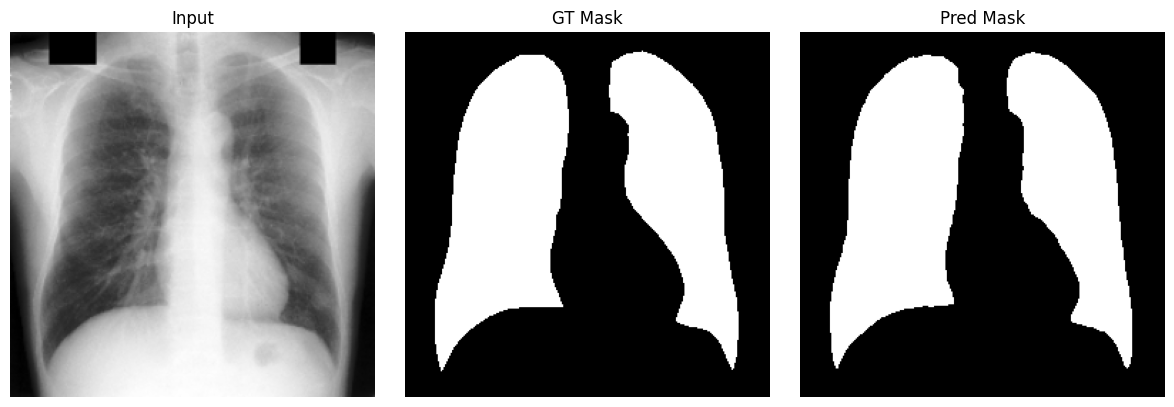

In [15]:
# 학습된 모델로 예측 마스크를 시각화합니다.
# 원본 이미지 / 정답 마스크 / 예측 마스크를 한 번에 보여줍니다.
#
# ⚠️ 주의: 이 노트북의 UNet은 마지막에 Sigmoid를 붙이지 않고 logits를 출력합니다.
#         따라서 시각화 시에는 torch.sigmoid(logits)로 확률맵(prob)을 만든 뒤,
#         threshold(기본 0.5)로 이진화하여 Pred Mask를 만듭니다.

import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def show_triplet_from_dataset(model, dataset, device, viz_idx=0, threshold=0.5):
    model.eval()

    img_t, mask_t = dataset[viz_idx]              # img_t: [1,H,W], mask_t: [1,H,W]
    x = img_t.unsqueeze(0).to(device)             # [1,1,H,W]

    logits = model(x)                             # [1,1,H,W] (logits)
    prob = torch.sigmoid(logits)[0, 0].cpu()      # [H,W] (0~1)
    pred_mask = (prob > threshold).float()        # [H,W] (0/1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.title('Input');   plt.imshow(img_t[0], cmap='gray');  plt.axis('off')
    plt.subplot(1,3,2); plt.title('GT Mask'); plt.imshow(mask_t[0], cmap='gray'); plt.axis('off')
    plt.subplot(1,3,3); plt.title('Pred Mask');plt.imshow(pred_mask, cmap='gray');plt.axis('off')
    plt.tight_layout()
    plt.show()

show_triplet_from_dataset(model, val_ds, device, viz_idx=0, threshold=0.5)

ㄴ